# Permutations as Strings

Reference implementation for experiments on **minimum-alphabet suffix-array realizations of permutations**(submitted to SPIRE'2026).

Given a permutation `π` of `0..n-1`, the code constructs the minimum-alphabet text `T_π` such that `SA(T_π) = π`.

**Contents:**
1. Source code (all modules)
2. Experiment: Orthogonality of $\sigma_{\min}$ vs. Classical Permutation-Complexity Measures


## 1. Setup & Source Code

In [ ]:
import os, math, random, csv, itertools
from collections import Counter, defaultdict
from functools import lru_cache
from itertools import permutations
from pathlib import Path
from typing import Dict, Hashable, List, Sequence, Tuple

os.makedirs('results/tables', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)
print('Directories ready.')

Directories ready.


In [ ]:
# ============================================================
# MODULE: min_realization
# Core construction and suffix-array verification
# ============================================================

def validate_perm(pi):
    n = len(pi)
    if sorted(pi) != list(range(n)):
        raise ValueError(f"not a permutation of 0..{n-1}: {pi}")

def inverse_perm(pi):
    validate_perm(pi)
    inv = [0] * len(pi)
    for i, x in enumerate(pi):
        inv[x] = i
    return inv

def descents(seq):
    return sum(1 for i in range(1, len(seq)) if seq[i-1] > seq[i])

def derived_permutation(pi):
    """Return R_pi, with -1 used for the shifted empty suffix."""
    validate_perm(pi)
    n = len(pi)
    inv = inverse_perm(pi)
    return [inv[x+1] if x < n-1 else -1 for x in pi]

def min_alphabet_size(pi):
    return descents(derived_permutation(pi)) + 1

def min_realization_labels(pi):
    validate_perm(pi)
    n = len(pi)
    if n == 0:
        return [], 0, []
    r = derived_permutation(pi)
    labels = [0] * n
    current = 0
    labels[pi[0]] = current
    for i in range(1, n):
        if r[i-1] > r[i]:
            current += 1
        labels[pi[i]] = current
    return labels, current + 1, r

def labels_to_string(labels):
    chars = []
    for v in labels:
        if v < 26:   chars.append(chr(ord('a') + v))
        elif v < 52: chars.append(chr(ord('A') + v - 26))
        else:        chars.append(chr(0xE000 + v - 52))
    return ''.join(chars)

def min_realization(pi, as_string=True):
    labels, sigma, r = min_realization_labels(pi)
    if as_string:
        return labels_to_string(labels), sigma, r
    return labels, sigma, r

def suffix_array(text):
    """Naive suffix array, suitable for experiments and verification."""
    return sorted(range(len(text)),
                  key=lambda i: tuple(text[i:]) if not isinstance(text, str) else text[i:])

def check_realization(pi):
    labels, _, _ = min_realization(pi, as_string=False)
    return suffix_array(labels) == list(pi)

def best_orientation(pi):
    inv = inverse_perm(pi)
    t1, s1, r1 = min_realization(pi)
    t2, s2, r2 = min_realization(inv)
    if s2 < s1:
        return {"orientation": "inverse", "permutation": inv, "text": t2, "sigma": s2, "R": r2}
    return {"orientation": "direct", "permutation": list(pi), "text": t1, "sigma": s1, "R": r1}

print('min_realization module loaded.')

min_realization module loaded.


In [ ]:
# ============================================================
# MODULE: bwt_index
# BWT and a small FM-index-style locate demonstration
# ============================================================

def bwt_from_sa(text, sa):
    """BWT without an explicit sentinel, using cyclic predecessor character."""
    n = len(text)
    if n == 0:
        return []
    return [text[(pos - 1) % n] for pos in sa]

def bwt(text):
    sa = suffix_array(text)
    return bwt_from_sa(text, sa), sa

def run_count(seq):
    if not seq:
        return 0
    return 1 + sum(1 for i in range(1, len(seq)) if seq[i] != seq[i-1])

def c_array(bwt_seq):
    counts = Counter(bwt_seq)
    total = 0
    c = {}
    for ch in sorted(counts):
        c[ch] = total
        total += counts[ch]
    return c

def rank_prefixes(bwt_seq):
    pref = [defaultdict(int)]
    cur = defaultdict(int)
    for ch in bwt_seq:
        cur = defaultdict(int, cur)
        cur[ch] += 1
        pref.append(cur)
    return pref

def lf_mapping(bwt_seq):
    c = c_array(bwt_seq)
    pref = rank_prefixes(bwt_seq)
    return [c[ch] + pref[i][ch] for i, ch in enumerate(bwt_seq)]

def sample_sa(sa, step):
    if step <= 0:
        raise ValueError("step must be positive")
    return {i: v for i, v in enumerate(sa) if v % step == 0}

def locate(sa_index, bwt_seq, samples):
    n = len(bwt_seq)
    if n == 0:
        raise ValueError("empty BWT")
    lf = lf_mapping(bwt_seq)
    pos = sa_index
    steps = 0
    while pos not in samples:
        pos = lf[pos]
        steps += 1
        if steps > n:
            raise RuntimeError("failed to reach a sampled SA position")
    return (samples[pos] + steps) % n, steps

def locate_all(bwt_seq, sa, step):
    samples = sample_sa(sa, step)
    vals = []
    total_steps = 0
    max_steps = 0
    for i in range(len(sa)):
        v, q = locate(i, bwt_seq, samples)
        vals.append(v)
        total_steps += q
        max_steps = max(max_steps, q)
    return vals, total_steps / max(1, len(sa)), max_steps

print('bwt_index module loaded.')

bwt_index module loaded.


In [ ]:
# ============================================================
# MODULE: metrics
# Metrics for permutations and strings
# ============================================================

def increasing_runs(pi):
    if not pi:
        return []
    runs = [[pi[0]]]
    for x in pi[1:]:
        if runs[-1][-1] < x:
            runs[-1].append(x)
        else:
            runs.append([x])
    return runs

def run_entropy(pi):
    n = len(pi)
    if n == 0:
        return 0.0
    h = 0.0
    for run in increasing_runs(pi):
        p = len(run) / n
        h += p * math.log2(1 / p)
    return h

def zero_order_entropy(seq):
    n = len(seq)
    if n == 0:
        return 0.0
    counts = Counter(seq)
    return sum((c / n) * math.log2(n / c) for c in counts.values())

def inversion_count(pi):
    return sum(1 for i in range(len(pi)) for j in range(i+1, len(pi)) if pi[i] > pi[j])

def lz78_phrase_count(seq):
    dictionary = set()
    i = 0
    phrases = 0
    n = len(seq)
    while i < n:
        cur = []
        j = i
        while j < n and tuple(cur + [seq[j]]) in dictionary:
            cur.append(seq[j])
            j += 1
        if j < n:
            cur.append(seq[j])
            dictionary.add(tuple(cur))
            j += 1
        phrases += 1
        i = j
    return phrases

def lz77_greedy_token_count(seq):
    n = len(seq)
    i = 0
    tokens = 0
    while i < n:
        best = 0
        for start in range(i):
            l = 0
            while i + l < n and seq[start + l] == seq[i + l]:
                l += 1
                if start + l >= i:
                    break
            best = max(best, l)
        i += max(1, best)
        tokens += 1
    return tokens

print('metrics module loaded.')

metrics module loaded.


In [ ]:
# ============================================================
# MODULE: eulerian_code
# Enumerative coding for minimum-alphabet classes
# ============================================================

def eulerian_table(n):
    A = [[0] * max(1, n) for _ in range(n + 1)]
    if n >= 1:
        A[1][0] = 1
    for i in range(2, n + 1):
        for d in range(i):
            val = 0
            if d < i - 1:
                val += (d + 1) * A[i-1][d]
            if d > 0:
                val += (i - d) * A[i-1][d-1]
            A[i][d] = val
    return A

def eulerian_number(n, d):
    if n == 0:
        return 1 if d == 0 else 0
    if d < 0 or d >= n:
        return 0
    return eulerian_table(n)[n][d]

@lru_cache(maxsize=None)
def class_perms(n, k):
    out = []
    for pi in permutations(range(n)):
        if min_alphabet_size(pi) == k:
            out.append(pi)
    return tuple(out)

def perm_to_index(pi):
    validate_perm(pi)
    n = len(pi)
    k = min_alphabet_size(pi)
    cls = class_perms(n, k)
    t = tuple(pi)
    try:
        r = cls.index(t)
    except ValueError as exc:
        raise RuntimeError("internal error: permutation not in its class") from exc
    return n, k, r

def index_to_perm(n, k, r):
    cls = class_perms(n, k)
    if r < 0 or r >= len(cls):
        raise ValueError(f"rank out of range for class size {len(cls)}")
    return list(cls[r])

def bit_length_for_class(n, k, include_n=True):
    bits = math.ceil(math.log2(max(1, n)))
    if include_n:
        bits += math.ceil(math.log2(max(1, n)))
    size = eulerian_number(n, k - 1)
    bits += math.ceil(math.log2(max(1, size)))
    return bits

print('eulerian_code module loaded.')

eulerian_code module loaded.


## 2. Experiment: Orthogonality of $\sigma_{\min}$ vs. Classical Permutation-Complexity Measures

This experiment supports the claim made in the paper's Introduction (Section 1,
"Suffix-Order Complexity vs. Classical Measures"):

> *"The measure $\sigma_{\min}(\pi)$ introduced in this paper is different in kind
> [from classical measures]. ... Thus $\sigma_{\min}$ does not measure
> monotonicity of $\pi$ itself; instead it measures monotonicity of the
> shifted-suffix order induced by $\pi$. It captures a suffix-order form of
> complexity that is not determined by classical monotone-run structure, and
> should be viewed as complementary to existing measures rather than a
> replacement for them."*

The paper illustrates this with a single hand-picked separating example
(Example 3: $\pi = [2,4,5,6,8,10,0,1,3,11,7,9]$, where $\sigma_{\min}(\pi)=6$ but
$\sigma_{\min}(\pi^{-1})=3$). Here we test the claim statistically, over many
random permutations, against two classical measures already cited in the
paper's Introduction:

- **Run entropy** $H_{\mathrm{run}}(\pi)$ (Barbay & Navarro, 2013) — captures
  monotone-run structure.
- **Inversion count** $\mathrm{inv}(\pi)$ (Pagh, 2002; McIlroy, 1993) — captures
  pairwise out-of-order structure.

We omit *increasing-run count* from the comparison since it is almost
perfectly correlated with run entropy (Spearman $\approx 0.96$ in our tests) —
the two are essentially the same signal viewed two ways, so including both
would be redundant.

**Two complementary statistics** are reported:

1. **Spearman rank correlation** between $\sigma_{\min}$ and each classical
   measure, across single random permutations. A value near zero indicates
   statistical independence. As a baseline for comparison, we also report the
   correlation *between* the two classical measures themselves.
2. **Pairwise ranking disagreement**: for random pairs $(\pi_1, \pi_2)$ of the
   same size, the percentage of pairs where $\sigma_{\min}$ orders them
   *oppositely* to a classical measure. A value near 50% indicates the two
   measures are statistically independent (a coin-flip relationship); a value
   near 0% or 100% would indicate strong agreement or strong disagreement,
   respectively.

All trials use fixed random seeds for exact reproducibility.

In [ ]:
def fisher_yates(n, rng):
    """Generate a uniformly random permutation of 0..n-1."""
    a = list(range(n))
    for i in range(n - 1, 0, -1):
        j = rng.randint(0, i)
        a[i], a[j] = a[j], a[i]
    return a

print('fisher_yates helper loaded.')

fisher_yates helper loaded.


In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt

def inversion_count_fast(pi):
    """O(n log n) merge-sort inversion count."""
    def sort_count(arr):
        n = len(arr)
        if n <= 1:
            return arr, 0
        mid = n // 2
        left, inv_l = sort_count(arr[:mid])
        right, inv_r = sort_count(arr[mid:])
        merged, i, j, inv_split = [], 0, 0, 0
        while i < len(left) and j < len(right):
            if left[i] <= right[j]:
                merged.append(left[i]); i += 1
            else:
                merged.append(right[j]); j += 1
                inv_split += len(left) - i
        merged.extend(left[i:]); merged.extend(right[j:])
        return merged, inv_l + inv_r + inv_split
    _, total = sort_count(list(pi))
    return total

def spearman_corr(xs, ys):
    n = len(xs)
    def rank(vals):
        order = sorted(range(n), key=lambda i: vals[i])
        ranks = [0] * n
        i = 0
        while i < n:
            j = i
            while j + 1 < n and vals[order[j+1]] == vals[order[i]]:
                j += 1
            avg_rank = (i + j) / 2 + 1
            for k in range(i, j + 1):
                ranks[order[k]] = avg_rank
            i = j + 1
        return ranks
    rx, ry = rank(xs), rank(ys)
    mx, my = sum(rx) / n, sum(ry) / n
    cov = sum((rx[i] - mx) * (ry[i] - my) for i in range(n))
    vx = sum((r - mx) ** 2 for r in rx)
    vy = sum((r - my) ** 2 for r in ry)
    return 0.0 if vx == 0 or vy == 0 else cov / (vx * vy) ** 0.5

N_VALUES_ORTHO    = [50, 100, 200]
TRIALS_ORTHO      = 3000
PAIR_TRIALS_ORTHO = 3000
SEED_ORTHO        = 2024
OUT_ORTHO_CORR    = 'results/tables/orthogonality_correlation.csv'
OUT_ORTHO_PAIRS   = 'results/tables/orthogonality_pairwise.csv'
OUT_BASELINE_CORR = 'results/tables/classical_measures_correlation.csv'

rows_corr, rows_pairs, rows_baseline = [], [], []
for n in N_VALUES_ORTHO:
    rng = random.Random(SEED_ORTHO + n)
    sigmas, run_entropies, invs = [], [], []
    for _ in range(TRIALS_ORTHO):
        pi = fisher_yates(n, rng)
        sigmas.append(min_alphabet_size(pi))
        run_entropies.append(run_entropy(pi))
        invs.append(inversion_count_fast(pi))

    rows_corr.append({
        'n': n, 'trials': TRIALS_ORTHO,
        'spearman_sigma_vs_runentropy': spearman_corr(sigmas, run_entropies),
        'spearman_sigma_vs_inversions': spearman_corr(sigmas, invs),
    })
    rows_baseline.append({
        'n': n,
        'spearman_runentropy_vs_inversions': spearman_corr(run_entropies, invs),
    })

    # Pairwise ranking disagreement: for random pairs (pi1, pi2),
    # does sigma_min order them oppositely to the classical measure?
    rng2 = random.Random(SEED_ORTHO + n + 1)
    dis_re = dis_inv = 0
    for _ in range(PAIR_TRIALS_ORTHO):
        pi1 = fisher_yates(n, rng2)
        pi2 = fisher_yates(n, rng2)
        s1, s2 = min_alphabet_size(pi1), min_alphabet_size(pi2)
        if s1 == s2:
            continue
        sign_sigma = 1 if s1 > s2 else -1

        re1, re2 = run_entropy(pi1), run_entropy(pi2)
        if re1 != re2 and (1 if re1 > re2 else -1) != sign_sigma:
            dis_re += 1
        i1, i2 = inversion_count_fast(pi1), inversion_count_fast(pi2)
        if i1 != i2 and (1 if i1 > i2 else -1) != sign_sigma:
            dis_inv += 1

    rows_pairs.append({
        'n': n, 'pair_trials': PAIR_TRIALS_ORTHO,
        'pct_disagree_runentropy': 100 * dis_re / PAIR_TRIALS_ORTHO,
        'pct_disagree_inversions': 100 * dis_inv / PAIR_TRIALS_ORTHO,
    })

df_corr = pd.DataFrame(rows_corr)
df_pairs = pd.DataFrame(rows_pairs)
df_baseline = pd.DataFrame(rows_baseline)
df_corr.to_csv(OUT_ORTHO_CORR, index=False)
df_pairs.to_csv(OUT_ORTHO_PAIRS, index=False)
df_baseline.to_csv(OUT_BASELINE_CORR, index=False)

print("=== Spearman correlation: sigma_min vs. classical measures ===")
print(df_corr.round(4).to_string(index=False))
print()
print("=== Spearman correlation: run entropy vs. inversions (baseline) ===")
print(df_baseline.round(4).to_string(index=False))
print()
print("=== Pairwise ranking disagreement (% of pairs sigma_min orders oppositely) ===")
print(df_pairs.round(2).to_string(index=False))

=== Spearman correlation: sigma_min vs. classical measures ===
  n  trials  spearman_sigma_vs_runentropy  spearman_sigma_vs_inversions
 50    3000                       -0.0435                       -0.0126
100    3000                       -0.0178                        0.0026
200    3000                       -0.0081                       -0.0149

=== Spearman correlation: run entropy vs. inversions (baseline) ===
  n  spearman_runentropy_vs_inversions
 50                             0.1325
100                             0.0503
200                             0.0081

=== Pairwise ranking disagreement (% of pairs sigma_min orders oppositely) ===
  n  pair_trials  pct_disagree_runentropy  pct_disagree_inversions
 50         3000                    42.07                    43.57
100         3000                    43.27                    46.00
200         3000                    45.60                    47.93


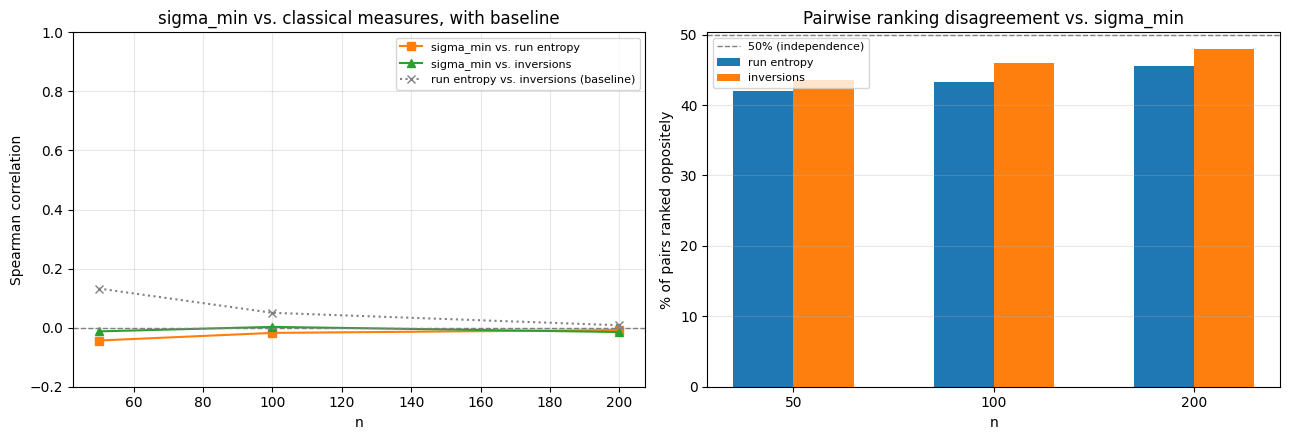

Saved: results/figures/orthogonality_test.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(df_corr['n'], df_corr['spearman_sigma_vs_runentropy'], marker='s', color='C1', label='sigma_min vs. run entropy')
ax.plot(df_corr['n'], df_corr['spearman_sigma_vs_inversions'], marker='^', color='C2', label='sigma_min vs. inversions')
ax.plot(df_baseline['n'], df_baseline['spearman_runentropy_vs_inversions'],
        marker='x', linestyle=':', color='gray', label='run entropy vs. inversions (baseline)')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylim(-0.2, 1.0)
ax.set_xlabel('n')
ax.set_ylabel('Spearman correlation')
ax.set_title('sigma_min vs. classical measures, with baseline')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
width = 0.3
xs = range(len(N_VALUES_ORTHO))
ax.bar([x - width/2 for x in xs], df_pairs['pct_disagree_runentropy'], width, label='run entropy')
ax.bar([x + width/2 for x in xs], df_pairs['pct_disagree_inversions'], width, label='inversions')
ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='50% (independence)')
ax.set_xticks(list(xs))
ax.set_xticklabels([str(n) for n in N_VALUES_ORTHO])
ax.set_xlabel('n')
ax.set_ylabel('% of pairs ranked oppositely')
ax.set_title('Pairwise ranking disagreement vs. sigma_min')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/orthogonality_test.png', dpi=120)
plt.show()
print('Saved: results/figures/orthogonality_test.png')

**Interpretation.** The Spearman correlations between $\sigma_{\min}$ and each
classical measure stay close to zero across all tested $n$, while the
baseline correlation between the two classical measures themselves is of
similar (small) magnitude — confirming $\sigma_{\min}$ is no more or less
independent of run entropy/inversions than those two already-recognized
measures are of each other. The pairwise disagreement rates climb toward 50%
as $n$ grows, meaning $\sigma_{\min}$ orders random permutation pairs close to
a coin flip relative to classical monotone-run and inversion-based measures.
Together, these results give quantitative, reproducible support for the
paper's claim that $\sigma_{\min}$ captures a suffix-order form of complexity
that is **not determined by classical monotone-run structure**.

## Summary of output files

| File | Description |
|------|-------------|
| `results/tables/orthogonality_correlation.csv` | Spearman correlation: sigma_min vs. run entropy / inversions |
| `results/tables/orthogonality_pairwise.csv` | Pairwise ranking disagreement: sigma_min vs. run entropy / inversions |
| `results/tables/classical_measures_correlation.csv` | Baseline: run entropy vs. inversions correlation |
| `results/figures/orthogonality_test.png` | Combined correlation + disagreement figure |

To download any file from Colab: `Files` panel (left sidebar) → navigate to the file → right-click → **Download**.

## 3. Experiment: Inverse-Permutation Optimization

This experiment supports **Proposition 1**: storing whichever of $\pi$ or
$\pi^{-1}$ has the smaller $\sigma_{\min}$, together with one orientation
bit, reduces the alphabet size relative to always storing $\pi$ directly.

For $10{,}000$ random permutations per $n \in \{20, 50, 100, 200\}$, we
compare $\sigma_{\min}(\pi)$ against $\sigma_{\min}(\pi^{-1})$ and report
three outcomes — the inverse is strictly better, the direct permutation is
already optimal, or the two tie — together with the mean and maximum
savings $\sigma_{\min}(\pi) - \sigma_{\min}(\pi^{-1})$ conditioned on the
inverse being strictly better.

Since $\pi$ and $\pi^{-1}$ are identically distributed under uniform
random sampling, "inverse better" and "direct better" should converge to
roughly equal proportions, with the tied fraction shrinking as $n$ grows
(ties become combinatorially less likely as the range of possible
$\sigma_{\min}$ values widens).# New Section

In [ ]:
import random
import pandas as pd

# ------------------------------------------------------------
# Inverse-permutation optimization: does choosing the better of
# pi and pi^-1 (Proposition 1) yield a real, growing reduction in
# sigma_min in practice? Reports a three-way outcome breakdown
# (inverse better / direct better / tied) plus the magnitude of
# savings conditioned on the inverse being strictly better.
# ------------------------------------------------------------

N_VALUES_INV = [20, 50, 100, 200]
TRIALS_INV   = 10000
SEED_INV     = 7
OUT_INV      = 'results/tables/inverse_optimization.csv'

rows_inv = []
for n in N_VALUES_INV:
    rng = random.Random(SEED_INV + n)
    inverse_better, direct_better, tied = 0, 0, 0
    savings_inv_better = []
    for _ in range(TRIALS_INV):
        pi = fisher_yates(n, rng)
        inv = inverse_perm(pi)
        s_pi = min_alphabet_size(pi)
        s_inv = min_alphabet_size(inv)
        if s_inv < s_pi:
            inverse_better += 1
            savings_inv_better.append(s_pi - s_inv)
        elif s_pi < s_inv:
            direct_better += 1
        else:
            tied += 1

    rows_inv.append({
        'n': n, 'trials': TRIALS_INV,
        'inverse_better_pct': 100 * inverse_better / TRIALS_INV,
        'direct_better_pct':  100 * direct_better  / TRIALS_INV,
        'tied_pct':           100 * tied           / TRIALS_INV,
        'mean_savings_given_inverse_better': (sum(savings_inv_better) / len(savings_inv_better)) if savings_inv_better else 0.0,
        'max_savings_given_inverse_better':  max(savings_inv_better) if savings_inv_better else 0,
    })

df_inv = pd.DataFrame(rows_inv)
df_inv.to_csv(OUT_INV, index=False)

print("=== Inverse-permutation optimization: outcome breakdown ===")
print(df_inv.round(2).to_string(index=False))

# sanity check: the three percentages must sum to 100 for every n
sums = df_inv['inverse_better_pct'] + df_inv['direct_better_pct'] + df_inv['tied_pct']
assert (sums.round(4) == 100.0).all(), sums.tolist()
print("\nCheck passed: inverse_better_pct + direct_better_pct + tied_pct == 100% for all n")

=== Inverse-permutation optimization: outcome breakdown ===
  n  trials  inverse_better_pct  direct_better_pct  tied_pct  mean_savings_given_inverse_better  max_savings_given_inverse_better
 20   10000               38.91              37.27     23.82                               1.75                                 6
 50   10000               43.80              42.12     14.08                               2.60                                10
100   10000               44.29              45.66     10.05                               3.59                                16
200   10000               46.80              46.31      6.89                               4.94                                23

Check passed: inverse_better_pct + direct_better_pct + tied_pct == 100% for all n
